# 01 — A Realistic Geology Data Workflow 🪨📊
**Companion notebook for the *Python for Geologists* course**

This notebook shows what a complete, research-style analysis looks like using the course's own
datasets. It ties together the skills from notebooks `2a_numpy`, `2b_pandas`, and `2c_matplotlib`.

We will work through **three mini case studies**:

| Part | Dataset | Task | Skills practiced |
|---|---|---|---|
| A | `rocks.csv` | Classify volcanic rocks on a TAS diagram | pandas groupby, scatter plots |
| B | `assay.csv` | Explore drillhole grades, handle missing data | filtering, NaN handling, downhole plots |
| C | `earthquakes.csv` | Clean a real messy catalog, analyze depth vs. magnitude | renaming columns, dates, histograms, maps |

> **How to use it:** run each cell, read the comments, then try the ✏️ *Your turn* challenges.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Locate the data folder (works both in this package and inside the course repo)
candidates = [Path("../data"), Path("data"), Path("../content/files"), Path("files")]
DATA = next(p for p in candidates if (p / "rocks.csv").exists())
print("Using data from:", DATA.resolve())

Using data from: /home/claude/pkg/data


---
## Part A — Volcanic Rock Geochemistry (`rocks.csv`)

Whole-rock major element analyses (wt% oxides) for volcanic rocks, sourced from the
**GEOROC** database. Each row is one analyzed sample; the `Name` column is the rock type.

In [2]:
rocks = pd.read_csv(DATA / "rocks.csv")
print("Shape:", rocks.shape)
rocks.head()

Shape: (22437, 10)


,Name,SiO2,Al2O3,CaO,Na2O,K2O,FeOT,MgO,MnO,TiO2
0,andesite,62.7,16.9,5.31,4.45,1.57,4.40,3.39,0.05,0.47
1,andesite,61.7,18.9,5.40,5.16,1.65,3.71,2.45,0.03,0.47
2,andesite,62.2,16.9,5.83,4.18,1.87,4.32,3.36,0.07,0.76
3,andesite,62.6,17.0,5.10,4.32,1.68,5.44,2.23,0.05,0.80
4,andesite,56.0,19.9,8.72,4.04,2.02,4.66,1.69,0.06,1.67


In [3]:
# Which rock types do we have, and how many samples of each?
rocks["Name"].value_counts()

Name
basalt      7171
andesite    6271
rhyolite    4968
dacite      4027
Name: count, dtype: int64

In [4]:
# Summary statistics per rock type — one line of pandas replaces an afternoon in Excel
rocks.groupby("Name")[["SiO2", "Na2O", "K2O", "MgO"]].mean().round(2)

,SiO2,Na2O,K2O,MgO
Name,,,,
andesite,57.19,3.49,1.69,3.87
basalt,49.31,2.80,1.08,6.81
dacite,65.69,3.82,2.59,1.67
rhyolite,73.47,3.49,4.04,0.45


### The TAS diagram (Total Alkali vs. Silica)
The classic classification plot for volcanic rocks: total alkalis (Na₂O + K₂O) against SiO₂.
Watch how a new column is created from two existing ones — *vectorized*, no loop needed.

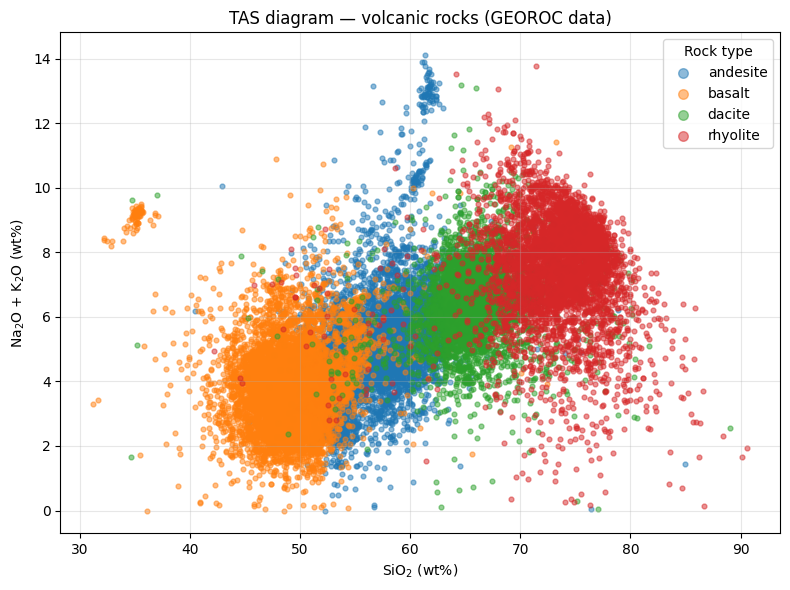

In [5]:
# Create the total-alkali column for ALL samples at once
rocks["Alkalis"] = rocks["Na2O"] + rocks["K2O"]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot each rock type with its own color and label
for name, group in rocks.groupby("Name"):
    ax.scatter(group["SiO2"], group["Alkalis"], s=12, alpha=0.5, label=name)

ax.set_xlabel("SiO$_2$ (wt%)")
ax.set_ylabel("Na$_2$O + K$_2$O (wt%)")
ax.set_title("TAS diagram — volcanic rocks (GEOROC data)")
ax.legend(title="Rock type", markerscale=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Notice how the rock types occupy distinct fields — basalt at low SiO₂, rhyolite at high SiO₂ —
exactly as the formal TAS classification predicts. You just reproduced a petrology-textbook figure
in ~10 lines.

✏️ **Your turn:**
1. Make a scatter of MgO vs. SiO₂ (a classic fractionation trend).
2. Compute which rock type has the highest average TiO₂.
3. Filter only samples with SiO₂ > 70 wt% — are they all rhyolites?

---
## Part B — Drillhole Assays (`assay.csv`)

Exploration drilling data: each row is a sampled interval (`FROM`–`TO`, in meters) from a
drillhole (`ID`), with copper (%), gold (g/t), silver (g/t), molybdenum (ppm) and more.
This is the everyday data of mineral exploration.

In [6]:
assay = pd.read_csv(DATA / "assay.csv")
print("Shape:", assay.shape)
print("Drillholes:", assay["ID"].nunique())
assay.head()

Shape: (8332, 11)
Drillholes: 55


,ID,FROM,TO,RECOV,CU_pct,AU_gpt,AG_gpt,DENSITY,MO_ppm,AS_ppm,S_pct
0,DH001,0.0,2.0,0.5,0.79,1.75,6.35,NaN,10.0,26.3,0.0
1,DH001,2.0,4.0,1.3,0.83,1.73,5.20,NaN,12.2,31.0,0.0
2,DH001,4.0,6.0,1.8,0.84,6.00,5.75,NaN,24.8,32.5,0.0
3,DH001,6.0,8.0,1.8,0.83,2.56,2.85,2.32,15.7,13.9,0.2
4,DH001,8.0,10.0,2.0,0.97,1.53,2.90,2.98,14.8,15.5,0.5


### Missing data — the first thing to check in ANY real dataset
Real lab data always has gaps. `NaN` (Not a Number) marks missing values.

In [7]:
missing = assay.isna().sum()
missing_pct = (missing / len(assay) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})

,missing_count,missing_%
ID,0,0.0
FROM,0,0.0
TO,0,0.0
RECOV,248,3.0
CU_pct,381,4.6
AU_gpt,83,1.0
AG_gpt,379,4.5
DENSITY,460,5.5
MO_ppm,379,4.5
AS_ppm,379,4.5


In [8]:
# Basic grade statistics (NaNs are ignored automatically)
assay[["CU_pct", "AU_gpt", "AG_gpt", "MO_ppm"]].describe().round(3)

,CU_pct,AU_gpt,AG_gpt,MO_ppm
count,7951.000,8249.000,7953.000,7953.000
mean,0.952,0.846,3.901,98.888
std,0.916,1.425,15.131,171.304
min,0.000,0.000,0.100,0.200
25%,0.330,0.250,1.350,7.700
50%,0.640,0.510,2.250,30.300
75%,1.290,1.000,3.850,118.400
max,9.290,43.600,505.000,3264.000


### Downhole grade plot
The standard visualization in exploration: grade vs. depth for a single hole.
Depth increases *downward*, so we invert the y-axis — a one-line trick worth remembering.

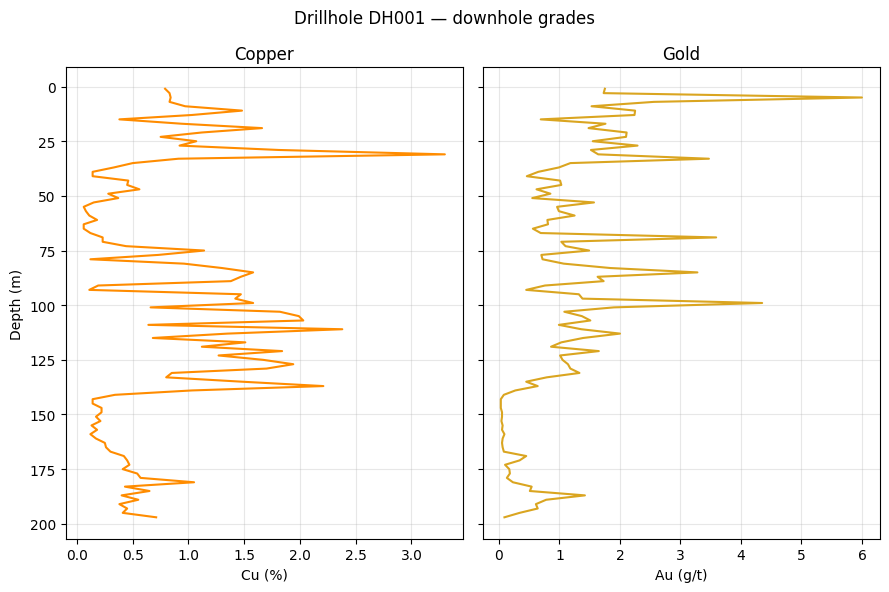

In [9]:
hole = assay[assay["ID"] == "DH001"].copy()
hole["MID"] = (hole["FROM"] + hole["TO"]) / 2      # interval midpoint depth

fig, axes = plt.subplots(1, 2, figsize=(9, 6), sharey=True)

axes[0].plot(hole["CU_pct"], hole["MID"], color="darkorange")
axes[0].set_xlabel("Cu (%)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Copper")

axes[1].plot(hole["AU_gpt"], hole["MID"], color="goldenrod")
axes[1].set_xlabel("Au (g/t)")
axes[1].set_title("Gold")

for ax in axes:
    ax.grid(alpha=0.3)
axes[0].invert_yaxis()          # depth increases downward
fig.suptitle("Drillhole DH001 — downhole grades")
plt.tight_layout()
plt.show()

### Ore-grade intervals with boolean filtering
Suppose the cutoff grade is **Cu ≥ 1.0 %**. Which intervals qualify?

In [10]:
cutoff = 1.0
ore = assay[assay["CU_pct"] >= cutoff]

print(f"Intervals at or above {cutoff}% Cu: {len(ore)} of {len(assay)} "
      f"({len(ore)/len(assay)*100:.1f}%)")

# Total ore meters per drillhole
ore_meters = (ore["TO"] - ore["FROM"]).groupby(ore["ID"]).sum().sort_values(ascending=False)
ore_meters.head(10)

Intervals at or above 1.0% Cu: 2768 of 8332 (33.2%)


ID
DH012    532.299988
DH028    425.049988
DH026    380.700012
DH029    332.299988
DH020    306.200012
DH053    299.549988
DH010    298.000000
DH038    291.399994
DH006    290.000000
DH018    224.000000
dtype: float64

✏️ **Your turn:**
1. Is Au correlated with Cu? Try `assay[["CU_pct","AU_gpt"]].corr()` and a scatter plot.
2. Compute a length-weighted average Cu grade per hole (hint: weight = `TO - FROM`).
3. Plot a histogram of Au grades — is it normal or log-normal? Try `ax.set_xscale("log")`.

---
## Part C — Earthquake Catalog (`earthquakes.csv`)

A catalog of Peruvian earthquakes since 1960. This file is deliberately *realistic and messy*:
the column headers are in **Spanish** with units and symbols in the names. Cleaning this kind of
file is a daily task in research — let's do it properly.

In [11]:
quakes_raw = pd.read_csv(DATA / "earthquakes.csv")
quakes_raw.head(3)

,fecha UTC,hora UTC,latitud (º),longitud (º),profundidad (km),magnitud (M)
0,13/01/1960,15:40:34.00,-16.145,-72.144,60,7.5
1,15/01/1960,09:30:24.00,-15.000,-75.000,70,7.0
2,17/01/1960,02:57:58.00,-14.500,-74.500,150,6.4


In [12]:
# Step 1: rename columns to clean, code-friendly English names
quakes = quakes_raw.rename(columns={
    "fecha UTC":        "date",
    "hora UTC":         "time",
    "latitud (º)":      "lat",
    "longitud (º)":     "lon",
    "profundidad (km)": "depth_km",
    "magnitud (M)":     "magnitude",
})

# Step 2: parse the date column into real datetime objects (day/month/year format)
quakes["date"] = pd.to_datetime(quakes["date"], format="%d/%m/%Y")
quakes["year"] = quakes["date"].dt.year

print(quakes.dtypes)
quakes.head(3)

date         datetime64[us]
time                    str
lat                 float64
lon                 float64
depth_km              int64
magnitude           float64
year                  int32
dtype: object


,date,time,lat,lon,depth_km,magnitude,year
0,1960-01-13,15:40:34.00,-16.145,-72.144,60,7.5,1960
1,1960-01-15,09:30:24.00,-15.000,-75.000,70,7.0,1960
2,1960-01-17,02:57:58.00,-14.500,-74.500,150,6.4,1960


In [13]:
# Overview: how many events, over what period, what magnitude range?
print(f"Events:     {len(quakes)}")
print(f"Period:     {quakes['year'].min()}–{quakes['year'].max()}")
print(f"Magnitude:  {quakes['magnitude'].min()} to {quakes['magnitude'].max()}")
print(f"Depth (km): {quakes['depth_km'].min()} to {quakes['depth_km'].max()}")

Events:     18933
Period:     1960–2021
Magnitude:  3.0 to 8.4
Depth (km): 0 to 743


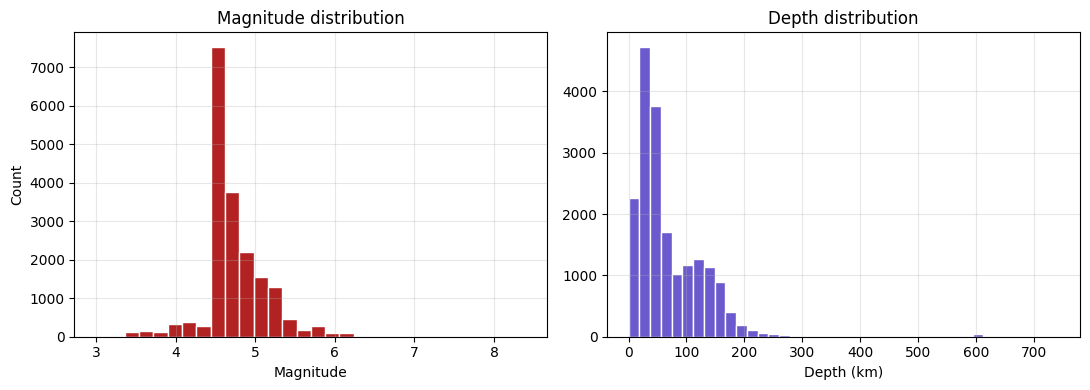

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(quakes["magnitude"], bins=30, color="firebrick", edgecolor="white")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count")
axes[0].set_title("Magnitude distribution")

axes[1].hist(quakes["depth_km"], bins=40, color="slateblue", edgecolor="white")
axes[1].set_xlabel("Depth (km)")
axes[1].set_title("Depth distribution")

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### An epicenter map — and the subducting slab, visible in raw data
Plot longitude vs. latitude colored by depth. Because Peru sits above the subducting Nazca plate,
earthquakes get **deeper toward the east (inland)** — a first-order tectonic feature you can see
with nothing but a scatter plot.

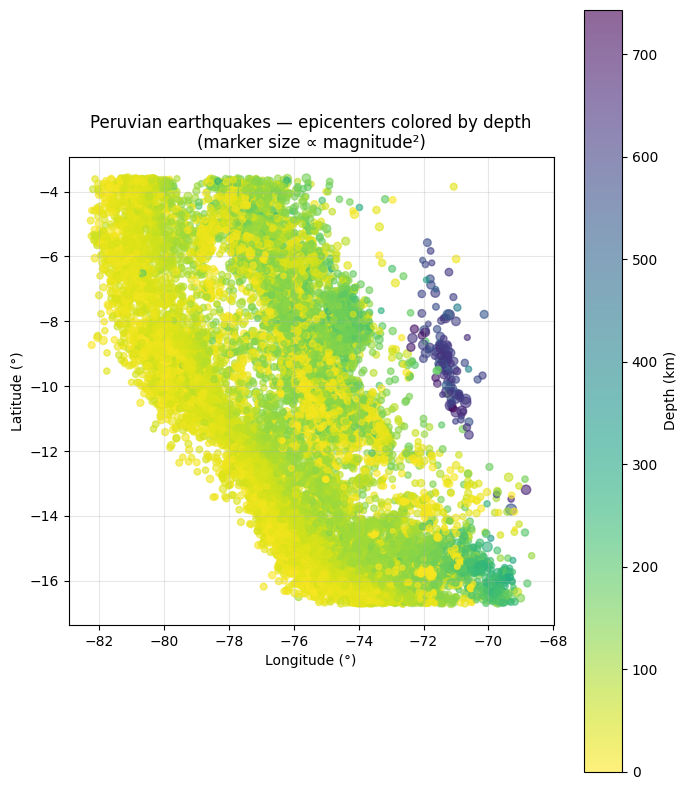

In [15]:
fig, ax = plt.subplots(figsize=(7, 8))

sc = ax.scatter(quakes["lon"], quakes["lat"],
                c=quakes["depth_km"], s=quakes["magnitude"]**2,
                cmap="viridis_r", alpha=0.6)

cbar = plt.colorbar(sc, ax=ax, label="Depth (km)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Peruvian earthquakes — epicenters colored by depth\n(marker size ∝ magnitude²)")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Your turn:**
1. Plot depth vs. longitude for a cross-section view — can you trace the slab geometry?
2. Count events per decade: `quakes.groupby(quakes['year'] // 10 * 10).size()`.
   Why do recent decades have more events? (Hint: it's about instruments, not tectonics.)
3. Filter only large events (M ≥ 7) and map them separately.

---
## Where to go from here
- Finish the course exercises in `content/5a_exercises.ipynb`.
- Redo Part A–C with **your own data** — that's when it truly sticks.
- Learn `scipy` (curve fitting, interpolation) and `geopandas` (shapefiles) next.
- Watch the course repository for the upcoming **Statistics** and **Machine Learning** chapters —
  the datasets you just mastered are exactly what those chapters will use.